# Linear Regression Project - NBA PPG Prediction

Goal: Building a multiple linear regression model from scratch (NumPy only, no sklearn) to predict a player's points per game (PPG), using a small set of box score features

In [1]:
import pandas as pd
import numpy as np

In [4]:
# importing more libraries of use

import copy, math

import numpy as np
import matplotlib.pyplot as plt

# plt.style.use('./deeplearning.mplstyle')

In [2]:
## read dataset

df = pd.read_csv("./datasets/nba_player_stats_2026.csv")

df

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,1629029,1,Luka Dončić,1610612747,LAL,64,2289,693,1457,0.476,...,495,530,105,34,255,153,2143,2146,2.08,0.41
1,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,68,2259,731,1321,0.553,...,292,448,95,52,151,139,2117,2189,2.97,0.63
2,1627759,3,Jaylen Brown,1610612738,BOS,71,2443,736,1543,0.477,...,492,364,72,27,259,191,2038,1817,1.41,0.28
3,201142,4,Kevin Durant,1610612745,HOU,78,2840,716,1376,0.520,...,426,372,62,71,246,142,2026,1992,1.51,0.25
4,1630178,5,Tyrese Maxey,1610612755,PHI,70,2661,694,1501,0.462,...,290,461,130,55,171,151,1980,1893,2.70,0.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,1643141,578,Jahmyl Telfort,1610612746,LAC,8,32,0,4,0.000,...,3,1,1,0,1,5,1,-2,1.00,1.00
578,1642935,579,Chucky Hepburn,1610612761,TOR,2,13,0,6,0.000,...,1,2,1,0,1,2,0,-3,2.00,1.00
579,1642468,579,Darius Brown,1610612739,CLE,1,3,0,1,0.000,...,1,0,0,0,0,0,0,0,0.00,0.00
580,1642855,579,Noa Essengue,1610612741,CHI,2,6,0,3,0.000,...,0,0,1,0,0,1,0,-2,0.00,0.00


In [9]:
df.head()

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,1629029,1,Luka Dončić,1610612747,LAL,64,2289,693,1457,0.476,...,495,530,105,34,255,153,2143,2146,2.08,0.41
1,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,68,2259,731,1321,0.553,...,292,448,95,52,151,139,2117,2189,2.97,0.63
2,1627759,3,Jaylen Brown,1610612738,BOS,71,2443,736,1543,0.477,...,492,364,72,27,259,191,2038,1817,1.41,0.28
3,201142,4,Kevin Durant,1610612745,HOU,78,2840,716,1376,0.520,...,426,372,62,71,246,142,2026,1992,1.51,0.25
4,1630178,5,Tyrese Maxey,1610612755,PHI,70,2661,694,1501,0.462,...,290,461,130,55,171,151,1980,1893,2.70,0.76


In [5]:
## get view of dataset

df.describe()

print(f"Columns are: {df.columns.tolist()}")

print(f"No. of rows are: {len(df)}")

Columns are: ['PLAYER_ID', 'RANK', 'PLAYER', 'TEAM_ID', 'TEAM', 'GP', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'EFF', 'AST_TOV', 'STL_TOV']
No. of rows are: 582


Features to use to predict PPG:

- FGA (Field goal attempts)
- Minutes played (MP)
- Free throw attempts (FTA)
- Three point attempts (3PA)

In [21]:
df_clean = df[["PTS", "FGA", "FG3A", "FTA", "GP"]] # features to be used for prediction

df_clean

,PTS,FGA,FG3A,FTA,GP
0,2143,1457,694,645,64
1,2117,1321,298,614,68
2,2038,1543,404,536,71
3,2026,1376,450,467,78
4,1980,1501,599,417,70
...,...,...,...,...,...
577,1,4,4,4,8
578,0,6,5,0,2
579,0,1,0,0,1
580,0,3,2,0,2


In [22]:
features = ["PTS", "FGA", "FG3A", "FTA", "GP"]

target = "PTS"

df_clean

,PTS,FGA,FG3A,FTA,GP
0,2143,1457,694,645,64
1,2117,1321,298,614,68
2,2038,1543,404,536,71
3,2026,1376,450,467,78
4,1980,1501,599,417,70
...,...,...,...,...,...
577,1,4,4,4,8
578,0,6,5,0,2
579,0,1,0,0,1
580,0,3,2,0,2


In [23]:
# calculating per game stats

for col in features[:-1]:  # excluding GP column
    df_clean[col] = df_clean[col]/df_clean['GP']

df_clean

,PTS,FGA,FG3A,FTA,GP
0,33.484375,22.765625,10.843750,10.078125,64
1,31.132353,19.426471,4.382353,9.029412,68
2,28.704225,21.732394,5.690141,7.549296,71
3,25.974359,17.641026,5.769231,5.987179,78
4,28.285714,21.442857,8.557143,5.957143,70
...,...,...,...,...,...
577,0.125000,0.500000,0.500000,0.500000,8
578,0.000000,3.000000,2.500000,0.000000,2
579,0.000000,1.000000,0.000000,0.000000,1
580,0.000000,1.500000,1.000000,0.000000,2


Prepare training data

In [ ]:
X_train = np.array(df_clean[features[1:]].values) # get everything except target column as features

Y_train = np.array(df_clean[target].values) # get target column as target variable

f"X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}"


array([[22.765625  , 10.84375   , 10.078125  , 64.        ],
       [19.42647059,  4.38235294,  9.02941176, 68.        ],
       [21.73239437,  5.69014085,  7.54929577, 71.        ],
       ...,
       [ 1.        ,  0.        ,  0.        ,  1.        ],
       [ 1.5       ,  1.        ,  0.        ,  2.        ],
       [ 0.2       ,  0.        ,  0.        ,  5.        ]],
      shape=(582, 4))

Initialise parameter vector w, and constant b

In [31]:
b_init = 0

w_init = np.zeros(X_train.shape[1])

f'b_init is: {b_init}, w_init is: {w_init}'

'b_init is: 0, w_init is: [0. 0. 0. 0.]'

In [46]:
X_train.shape

(582, 4)

### Prediction with Multiple Variables

In [ ]:
def predict_single_loop(w, x, b):
    """
    predict using linear regression

    x: input with multiple features
    w: vector of model params
    b: model params scalar
    
    """

    # initialising variables
    n = x.shape[0]
    p = 0
    for i in range(n):
        p_i = x[i] *w[i]
        p += p_i

    p = p + b

    return p

In [40]:
# predict using single row from training data

x_vec = X_train[np.random.randint(0, len(df_clean))] #selecting a random row for lolz

# make a prediction

f_wb = predict_single_loop(x_vec, w_init, b_init)

print(f"f_wb shape: {f_wb.shape}, prediction: {f_wb}") # this prediction makes sense as we've initialised all our parameters to be 0


f_wb shape: (), prediction: 0.0


Prediction using dot product for vectors

In [41]:
def predict(x, w, b):

    p = np.dot(x, w) + b

    return p

### Implement Cost Function (Mean Squared Error)

In [43]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b
        cost = cost + (f_wb_i - y[i]) ** 2

    cost = cost / (2 * m)

    return cost


In [45]:
## test compute_cost functionality

compute_cost(X_train, Y_train, w_init, b_init) # obtain cost so we can now implement gradient descent

np.float64(62.199615886285834)

### Implement gradient descent (for multiple variables/features)

In [58]:
# compute gradient

def compute_gradient(x, y, w, b):
    m,n = x.shape # we are now dealing with multiple features, so we must consider the cost for each feature, for each data point
    
    #let "j" be cost
    # initialising variables
    dj_dw = np.zeros((n, ))
    dj_db = 0.

    for i in range(m): # computing for each data point
        error = (np.dot(x[i], w) + b) - y[i] # computing error/cost
        for j in range (n): # computing for each feature
            dj_dw[j] = dj_dw[j] + error * x[i, j]
        dj_db += error

    dj_dw = dj_dw / m
    dj_db = dj_db / m 

    return dj_dw, dj_db

In [60]:
# compute and display gradient

tmp_dj_dw, tmp_dj_db = compute_gradient(X_train, Y_train, w_init, b_init)

print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: {tmp_dj_dw}')

dj_db at initial w,b: -9.15437042341797
dj_dw at initial w,b: [ -94.09727986  -37.39895834  -27.10691945 -488.65120275]


### Gradient descent with multiple variables

In [64]:
# compute gradient descent
def gradient_descent(X, y, w_in, b_in, alpha, num_iters, cost_func, gradient_func):
    J_history = [] # History of cost values (J, w)
    w = copy.deepcopy(w_in) # avoid modifying global w_in within function
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        dj_dw, dj_db = gradient_func(X, y, w, b)

        b = b - alpha * dj_db
        w = w - alpha * dj_dw
        
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append(cost_func(X, y, w, b))
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e}")   
    
    return w, b, J_history

Gradient descent to get ideal parameters for w and b

In [65]:
# initialise params

w_init = np.zeros_like(w_init)
b_init = 0.

iterations = 10000
alpha = 5.0e-7

# execute gradient descent

w_final, b_final, J_hist = gradient_descent(X_train, Y_train, w_init, b_init, alpha, iterations, compute_cost, compute_gradient)

Iteration    0: Cost 6.21e+01
Iteration 1000: Cost 1.98e+01
Iteration 2000: Cost 1.68e+01
Iteration 3000: Cost 1.63e+01
Iteration 4000: Cost 1.59e+01
Iteration 5000: Cost 1.56e+01
Iteration 6000: Cost 1.52e+01
Iteration 7000: Cost 1.49e+01
Iteration 8000: Cost 1.45e+01
Iteration 9000: Cost 1.42e+01


In [66]:
print(f"(w, b) found by gradient descent: ({w_final}, {b_final:8.4f})")

(w, b) found by gradient descent: ([0.14329455 0.05136927 0.0487306  0.15652176],   0.0068)


Now want to plot cost vs. iteration

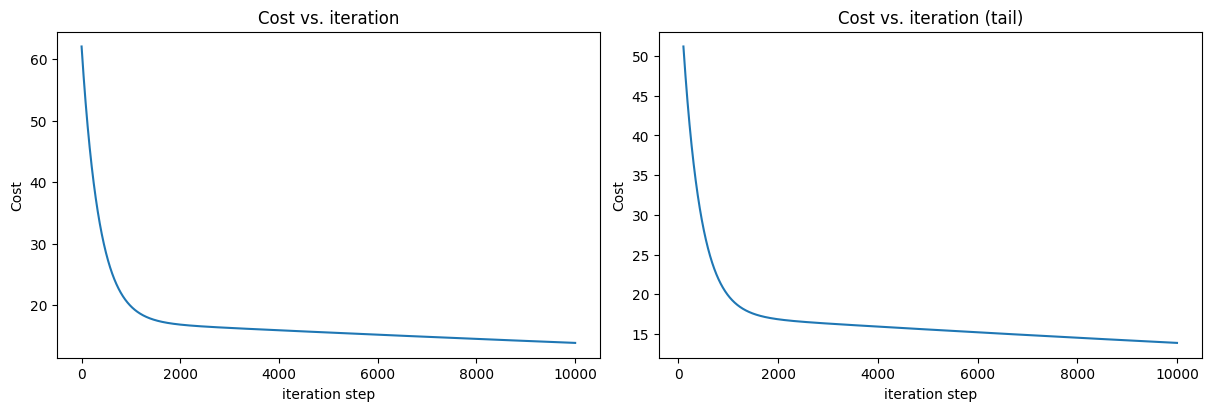

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])

ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

Plotting predicted vs actual (should be close to minimal cost)

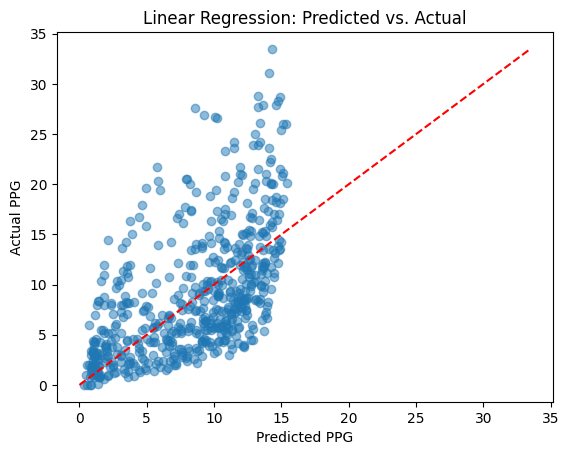

In [68]:
Y_pred = predict(X_train, w_final, b_final)

plt.scatter(Y_pred, Y_train, alpha=0.5)

plt.plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--')
plt.xlabel("Predicted PPG")
plt.ylabel("Actual PPG")
plt.title("Linear Regression: Predicted vs. Actual")
plt.show()

Prediction is still not accurate, and needs improvement!